<a href="https://colab.research.google.com/github/DavidZD5/Mineria-de-datos/blob/main/Luz_Inteligente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<div align="center">

# Universidad Politécnica de San Luis Potosí
## Ingeniería en Tecnologías de la Información
### Materia: Minería de Datos

---

#   Proyecto Final
# Reconocimiento de Voz "Luz Inteligente"

---

| Campo | Detalle |
|---|---|
| **Proyecto** | Luz Inteligente — Reconocimiento de Voz |
| **Alumna1** | *Carol Elizabeth Cortés Beltrán - 177203*|
| **Alumna2** | *Dafne Karina Jasso Rodriguez - 171513*|
| **Alumno3** | *David Zarate Dominguez - 175842*|
| **Grupo** | T48A  6:00–7:00 PM |
| **Fecha de entrega** | 25 de mayo de 2026 |
| **Profesor** | Jesús Alberto Revilla Silva
|

---

</div>

---

##   Índice

1. [Introducción Teórica](#introduccion)
   - 1.1 [Procesamiento de Señales de Audio](#audio)
   - 1.2 [Coeficientes Cepstrales en Frecuencias de Mel (MFCC)](#mfcc)
   - 1.3 [Redes Neuronales Densas (MLP)](#mlp)
2. [Fase 2 — Adquisición y Procesamiento de Datos](#fase2)
   - 2.1 [Recolección del Dataset](#dataset)
   - 2.2 [Extracción de Características](#features)
   - 2.3 [Normalización y Padding](#normalizacion)
3. [Fase 3 — Desarrollo del Modelo y Optimización](#fase3)
   - 3.1 [Arquitectura Base](#arquitectura)
   - 3.2 [Experimentación y Tuning](#tuning)
   - 3.3 [Entrenamiento](#entrenamiento)
4. [Fase 4 — Evaluación y Resultados](#fase4)
   - 4.1 [Simulación de Salida](#simulacion)
   - 4.2 [Prueba Ciega](#prueba)
5. [Conclusiones](#conclusiones)

---

## 1. Introducción Teórica <a name="introduccion"></a>

---

### 1.1 Procesamiento de Señales de Audio <a name="audio"></a>

El audio es, en su naturaleza fundamental, una **señal analógica continua**: una variación de presión en el aire que se propaga en el tiempo. Para que una computadora pueda analizarla, esta señal debe pasar por un proceso de **digitalización** que comprende dos etapas principales:

- **Muestreo (Sampling):** Se toman *n* muestras por segundo de la señal continua. Este valor se denomina **frecuencia de muestreo** (*sample rate*) y se mide en Hertz (Hz). El estándar de calidad para voz humana es generalmente **16,000 Hz** (16 kHz), lo que significa que se capturan 16,000 valores numéricos por cada segundo de audio. El **Teorema de Nyquist-Shannon** establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima de la señal para evitar el fenómeno de *aliasing* (distorsión).

- **Cuantización:** Cada muestra tomada se representa mediante un número finito de bits. La resolución típica es de **16 bits**, lo que permite representar 2¹⁶ = 65,536 niveles de amplitud distintos.

El resultado es una secuencia discreta de números que representa la forma de onda (*waveform*) del audio en el dominio del tiempo. Sin embargo, trabajar directamente con esta representación temporal para tareas de reconocimiento de voz es computacionalmente costoso e ineficiente, ya que no captura de forma intuitiva las **características perceptuales** del sonido. Por ello, es necesario transformar la señal al **dominio de la frecuencia**, utilizando herramientas como la **Transformada de Fourier de Corto Plazo (STFT)**, que analiza el contenido frecuencial de la señal en ventanas de tiempo pequeñas y superpuestas, generando una representación conocida como **espectrograma**.

---

### 1.2 Coeficientes Cepstrales en Frecuencias de Mel (MFCC) <a name="mfcc"></a>

Los **MFCC** (*Mel-Frequency Cepstral Coefficients*) son, en la actualidad, la representación de características (*feature*) más utilizada en sistemas de reconocimiento automático de voz (ASR) y clasificación de audio. Su popularidad se debe a que imitan la forma en que el **sistema auditivo humano** percibe el sonido.

**¿Por qué no usar el espectrograma directamente?**

El espectrograma distribuye las frecuencias en una escala **lineal**, pero el oído humano *no* percibe las frecuencias de forma lineal. Somos mucho más sensibles a las diferencias en frecuencias bajas (voz, instrumentos) que en frecuencias muy altas. Para modelar esto, se utiliza la **escala Mel**, una escala psicoacústica que comprime las frecuencias altas y expande las bajas, reflejando la percepción auditiva real.

**Pipeline de cálculo de MFCC:**

El resultado final es una **matriz 2D** de dimensiones `(n_mfcc × n_frames)`, donde cada columna es el vector de coeficientes en un instante de tiempo. Esta representación compacta y robusta es la que alimentará nuestra red neuronal.

**¿Por qué los MFCC son ideales para este proyecto?**

| Propiedad | Beneficio |
|---|---|
| Escala perceptual Mel | Enfatiza las frecuencias relevantes para la voz humana |
| Compresión de información | Representa ~1 segundo de audio en solo 40 coeficientes |
| Invarianza relativa | Robustez ante variaciones de volumen y timbre |
| Estándar industrial | Usado en Siri, Google Assistant, Alexa |

---

### 1.3 Redes Neuronales Densas (MLP) <a name="mlp"></a>

Un **Perceptrón Multicapa** (*Multilayer Perceptron*, MLP) es la arquitectura de red neuronal artificial más fundamental. Se denomina "densa" porque **cada neurona de una capa está conectada con todas las neuronas de la capa siguiente** (*fully connected*). Su estructura se compone de tres tipos de capas:

ENTRADA          CAPAS OCULTAS         SALIDA

**Componentes clave:**

- **Función de Activación ReLU** (*Rectified Linear Unit*): `f(x) = max(0, x)`. Es la función de activación más utilizada en capas ocultas porque resuelve el problema del *vanishing gradient*, permite el aprendizaje profundo y es computacionalmente eficiente.

- **Función de Activación Sigmoide** (capa de salida): `f(x) = 1 / (1 + e⁻ˣ)`. Comprime la salida al rango `[0, 1]`, interpretándose directamente como una **probabilidad**, lo que la hace ideal para clasificación binaria:
  - Salida → 1.0 : "Encender Luz"
  - Salida → 0.0 : "Apagar Luz"

- **Función de Pérdida — Binary Crossentropy:** Mide la diferencia entre la predicción del modelo y la etiqueta real. Se minimiza durante el entrenamiento mediante el algoritmo de **retropropagación** (*backpropagation*) y el optimizador **Adam**.

- **Dropout** (regularización): Técnica que desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento para prevenir el **sobreajuste** (*overfitting*), mejorando la capacidad de generalización del modelo.

**¿Por qué MLP y no CNN o RNN para este problema?**

Dado que nuestro dataset es relativamente pequeño (122 muestras), una arquitectura densa (MLP) es la opción más adecuada por su **simplicidad**, **velocidad de entrenamiento** y menor riesgo de sobreajuste comparado con arquitecturas más complejas. El objetivo pedagógico del proyecto también justifica comenzar con esta base sólida.

---

In [29]:
!pip install librosa -q

import os                             # Navegación del sistema de archivos
import warnings                       # Manejo de advertencias
import numpy as np                    # Operaciones numéricas y matriciales
import pandas as pd                   # Procesamiento de datos tabulares

# Librerías de audio
import librosa                        # Extracción de características de audio
import librosa.display                # Herramientas de visualización de audio

# Librerías de visualización gráfica
import matplotlib.pyplot as plt       # Gráficas base (ondas, espectrogramas)
import matplotlib.patches as mpatches # Formatos avanzados de gráficos
import seaborn as sns                 # Gráficas estadísticas (Matriz de confusión)

from google.colab import drive

# TensorFlow y Keras (Construcción del modelo Deep Learning)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Scikit-learn (Métricas y preparación de datos)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Desactivar advertencias no críticas para mantener limpia la consola
warnings.filterwarnings('ignore')

# Configuración de Entorno y Reproducibilidad
# Definimos un valor único para la semilla aleatoria. El número 42 es un estándar industrial.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ------------------------------------------------------------------------------
# Montaje de Google Drive y Verificación de Rutas
# ------------------------------------------------------------------------------
print("=== Iniciando Montaje de Google Drive ===")
# Esto lanzará una ventana emergente en Colab pidiendo accesos a la cuenta
drive.mount('/content/drive')

print("=== Iniciando Montaje de Google Drive ===")
drive.mount('/content/drive')


RUTA_PROYECTO = '/content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto'
RUTA_AUDIOS = os.path.join(RUTA_PROYECTO, 'Librosa')


print("COMPROBACIÓN DE RUTA DE AUDIOS")

if os.path.exists(RUTA_AUDIOS):
    print("¡Conexión exitosa! Carpeta de audios localizada en Drive.")

    # Listar los archivos que se encuentran dentro de 'Librosa'
    archivos = os.listdir(RUTA_AUDIOS)
    print(f"📂 Carpeta destino: '{os.path.basename(RUTA_AUDIOS)}'")
    print(f"📋 Total de elementos detectados: {len(archivos)}")

    if len(archivos) > 0:
        print(f"🎵 Muestra de los primeros archivos encontrados: {archivos[:5]}")
    else:
        print("⚠️ La carpeta está vacía. Asegúrate de haber subido los audios .wav a esa ubicación.")
else:
    print("❌ ERROR: No se pudo acceder a la carpeta de audios.")
    print(f"Ruta buscada: {RUTA_AUDIOS}")
    print("\n💡 Consejos para solucionar el problema:")
    print("1. Verifica haber creado el 'Acceso directo' en tu propia cuenta de Drive (Mi unidad).")
    print("2. Verifica que el nombre de la variable RUTA_PROYECTO coincida con el nombre del acceso directo.")
    print("3. Asegúrate de aceptar todos los permisos al montar Google Drive.")
print("=" * 60)

=== Iniciando Montaje de Google Drive ===
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Iniciando Montaje de Google Drive ===
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COMPROBACIÓN DE RUTA DE AUDIOS
¡Conexión exitosa! Carpeta de audios localizada en Drive.
📂 Carpeta destino: 'Librosa'
📋 Total de elementos detectados: 22
🎵 Muestra de los primeros archivos encontrados: ['apagar_luz(1).wav', 'Apagar_luz(3).wav', 'Apagar_Luz(2).wav', 'apagar_luz.wav', 'Apagar_Luz_18.wav']


---

## 2. Fase 2 — Adquisición y Procesamiento de Datos <a name="fase2"></a>

En esta fase se realizan tres operaciones fundamentales que transforman los archivos
de audio crudos (.wav o .mp3) en tensores numéricos aptos para alimentar la red neuronal.

El pipeline completo es:

```
Archivos de audio en Drive
         │
         ▼
  Lectura con librosa
         │
         ▼
  Extracción de MFCC (40 coeficientes)
         │
         ▼
  Padding / Truncado → longitud fija
         │
         ▼
  Normalización (Media=0, Std=1)
         │
         ▼
  Aplanado → Vector 1D
         │
         ▼
  Dataset listo para el modelo
```

In [30]:
# ============================================================
# FASE 2 — Adquisición y Procesamiento de Datos
# Recolección del dataset
# ============================================================

RUTA_BASE = "/content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/Librosa"

# Extensiones de audio aceptadas
EXTENSIONES_VALIDAS = ('.wav', '.mp3', '.ogg', '.flac', '.m4a')

# ----------------------------------------------------------
# Función de exploración: recorre carpetas y recopila metadata
# ----------------------------------------------------------
def explorar_dataset(ruta_base):
    """
    Recorre la estructura de carpetas y devuelve un DataFrame
    con la ruta, etiqueta y nombre de cada archivo de audio.

    Parámetros:
        ruta_base (str): Ruta raíz donde están las subcarpetas de clases.

    Retorna:
        pd.DataFrame con columnas: ['ruta', 'etiqueta', 'archivo']
    """
    registros = []

    # Verificar que la ruta base exista
    if not os.path.exists(ruta_base):
        raise FileNotFoundError(
            f"No se encontró la ruta: {ruta_base}\n"
            "Verifica que Drive esté montado y la ruta sea correcta."
        )

    # Recorrer cada subcarpeta (cada una = una clase/etiqueta)
    carpetas = sorted([
        d for d in os.listdir(ruta_base)
        if os.path.isdir(os.path.join(ruta_base, d))
    ])

    if len(carpetas) == 0:
        raise ValueError(
            "No se encontraron subcarpetas en la ruta base.\n"
            "Asegúrate de tener carpetas como 'encender_luz/' y 'apagar_luz/'"
        )

    for carpeta in carpetas:
        ruta_carpeta = os.path.join(ruta_base, carpeta)
        archivos = sorted([
            f for f in os.listdir(ruta_carpeta)
            if f.lower().endswith(EXTENSIONES_VALIDAS)
        ])

        for archivo in archivos:
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            registros.append({
                'ruta'    : ruta_completa,
                'etiqueta': carpeta,       # Nombre de carpeta = clase
                'archivo' : archivo
            })

    return pd.DataFrame(registros)


# ----------------------------------------------------------
# Ejecutar exploración
# ----------------------------------------------------------
df_dataset = explorar_dataset(RUTA_BASE)

# ----------------------------------------------------------
# Reporte de exploración
# ----------------------------------------------------------
print("=" * 55)
print(" REPORTE DE EXPLORACIÓN DEL DATASET")
print("=" * 55)
print(f"\n Ruta base       : {RUTA_BASE}")
print(f" Total de audios : {len(df_dataset)}")
print(f"  Clases detectadas: {df_dataset['etiqueta'].nunique()}")
print()

# Distribución por clase
print("─" * 35)
print("  Distribución por clase:")
print("─" * 35)
conteo_clases = df_dataset['etiqueta'].value_counts()
for clase, cantidad in conteo_clases.items():
    barra = "█" * cantidad
    print(f"  [{clase}]")
    print(f"   {barra} ({cantidad} audios)")
print("─" * 35)

# Verificación de balance
if len(conteo_clases) == 2:
    clases = list(conteo_clases.values)
    diferencia = abs(clases[0] - clases[1])
    if diferencia == 0:
        print("\n   Dataset BALANCEADO perfectamente.")
    elif diferencia <= 5:
        print(f"\n    Dataset casi balanceado (diferencia: {diferencia} audios).")
    else:
        print(f"\n   Dataset DESBALANCEADO (diferencia: {diferencia} audios).")
        print("     Considera técnicas de balanceo (oversampling/undersampling).")

print()
print(" Primeros 5 registros:")
print(df_dataset.head())

 REPORTE DE EXPLORACIÓN DEL DATASET

 Ruta base       : /content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/Librosa
 Total de audios : 40
  Clases detectadas: 2

───────────────────────────────────
  Distribución por clase:
───────────────────────────────────
  [apagar_luz]
   █████████████████████ (21 audios)
  [encender_luz']
   ███████████████████ (19 audios)
───────────────────────────────────

    Dataset casi balanceado (diferencia: 2 audios).

 Primeros 5 registros:
                                                ruta    etiqueta  \
0  /content/drive/MyDrive/UPSLP/9 semestre plus/M...  apagar_luz   
1  /content/drive/MyDrive/UPSLP/9 semestre plus/M...  apagar_luz   
2  /content/drive/MyDrive/UPSLP/9 semestre plus/M...  apagar_luz   
3  /content/drive/MyDrive/UPSLP/9 semestre plus/M...  apagar_luz   
4  /content/drive/MyDrive/UPSLP/9 semestre plus/M...  apagar_luz   

             archivo  
0  Apagar Luz(1).wav  
1     Apagar Luz.wav  
2  Apagar luz(2).wav  
3 

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  HIPERPARÁMETROS DE EXTRACCIÓN DE AUDIO
  Sample Rate   : 16000 Hz
  N_MFCC        : 40 coeficientes
  N_FFT         : 512 muestras por ventana
  Hop Length    : 256 muestras
  Duración máx  : 2.0 segundos
  Frames máx    : 125 frames por audio
  Shape MFCC    : (40, 125) por muestra

🔄 Iniciando extracción de MFCC...

  [██████████████████████████████] 40/40 — encender_luz'/encenderluz(1).wav

 EXTRACCIÓN DE MFCC COMPLETADA
  Audios procesados : 40
  Audios con error  : 0
  Shape por muestra : (40, 125)


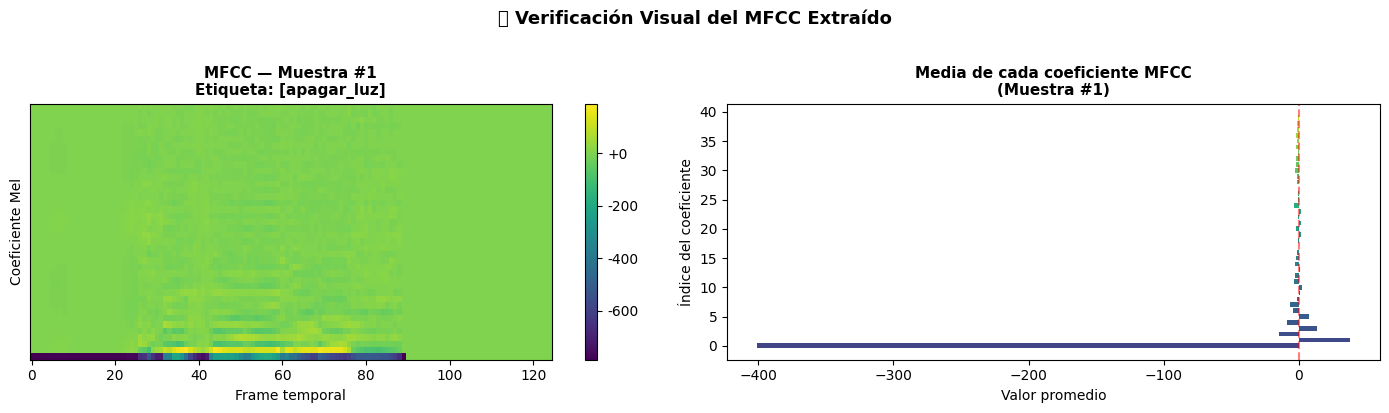

  📊 Visualización guardada como 'verificacion_mfcc.png'


In [32]:
# ============================================================
# FASE 2 — PASO 2.2: Extracción de Características (MFCC)
# ============================================================

# ----------------------------------------------------------
# Hiperparámetros de extracción de audio
# ----------------------------------------------------------

SAMPLE_RATE  = 16000   # 16 kHz: estándar para señales de voz humana
N_MFCC       = 40      # Número de coeficientes Mel. 40 captura
                       # fonemas con alta fidelidad sin redundancia excesiva.
N_FFT        = 512     # Tamaño de ventana FFT (~32ms a 16kHz).
                       # Ventanas más largas = mejor resolución frecuencial.
HOP_LENGTH   = 256     # Desplazamiento entre ventanas (50% solapamiento).
                       # Solapamiento del 50% es el estándar en ASR.
DURACION_MAX = 2.0     # Duración máxima en segundos a considerar.
                       # Audios más largos se truncan; más cortos se rellenan.

# Longitud fija en frames: cuántas columnas tendrá la matriz MFCC
MAX_FRAMES = int(np.ceil(SAMPLE_RATE * DURACION_MAX / HOP_LENGTH))

print("=" * 55)
print("  HIPERPARÁMETROS DE EXTRACCIÓN DE AUDIO")
print("=" * 55)
print(f"  Sample Rate   : {SAMPLE_RATE} Hz")
print(f"  N_MFCC        : {N_MFCC} coeficientes")
print(f"  N_FFT         : {N_FFT} muestras por ventana")
print(f"  Hop Length    : {HOP_LENGTH} muestras")
print(f"  Duración máx  : {DURACION_MAX} segundos")
print(f"  Frames máx    : {MAX_FRAMES} frames por audio")
print(f"  Shape MFCC    : ({N_MFCC}, {MAX_FRAMES}) por muestra")
print("=" * 55)


# ----------------------------------------------------------
# Función principal de extracción de MFCC
# ----------------------------------------------------------
def extraer_mfcc(ruta_archivo,
                 sr=SAMPLE_RATE,
                 n_mfcc=N_MFCC,
                 n_fft=N_FFT,
                 hop_length=HOP_LENGTH,
                 max_frames=MAX_FRAMES):
    """
    Carga un archivo de audio y extrae sus coeficientes MFCC.

    Proceso interno:
      1. Carga el audio y lo remuestrea a `sr` Hz (mono).
      2. Calcula los MFCC usando la STFT con ventana de Hamming.
      3. Aplica padding (relleno con ceros) si el audio es corto,
         o truncado si es demasiado largo.

    Parámetros:
        ruta_archivo (str): Ruta al archivo de audio.
        sr, n_mfcc, n_fft, hop_length, max_frames: Ver hiperparámetros.

    Retorna:
        np.ndarray de shape (n_mfcc, max_frames) o None si hay error.
    """
    try:
        # Paso 1: Cargar audio (mono, remuestreado a sr Hz)
        señal, _ = librosa.load(ruta_archivo, sr=sr, mono=True)

        # Paso 2: Extraer MFCC
        # Resultado shape: (n_mfcc, n_frames_original)
        mfcc = librosa.feature.mfcc(
            y=señal,
            sr=sr,
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            hop_length=hop_length
        )

        # Paso 3: Padding o Truncado para longitud fija
        if mfcc.shape[1] < max_frames:
            # Audio corto → rellenar con ceros a la derecha
            pad_ancho = max_frames - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_ancho)), mode='constant')
        else:
            # Audio largo → recortar a max_frames
            mfcc = mfcc[:, :max_frames]

        # Shape final garantizada: (n_mfcc, max_frames)
        return mfcc

    except Exception as e:
        print(f"   Error procesando '{os.path.basename(ruta_archivo)}': {e}")
        return None


# ----------------------------------------------------------
# Extracción de MFCC para TODO el dataset con barra de progreso
# ----------------------------------------------------------
print("\n🔄 Iniciando extracción de MFCC...\n")

lista_mfcc    = []   # Almacena matrices MFCC de cada audio
lista_etiquetas = [] # Almacena la etiqueta correspondiente
lista_errores   = [] # Registra archivos con problemas

total = len(df_dataset)

for idx, fila in df_dataset.iterrows():
    mfcc = extraer_mfcc(fila['ruta'])

    if mfcc is not None:
        lista_mfcc.append(mfcc)
        lista_etiquetas.append(fila['etiqueta'])
    else:
        lista_errores.append(fila['archivo'])

    # Barra de progreso manual (compatible con Colab)
    progreso = (idx + 1) / total
    bloques  = int(progreso * 30)
    barra    = "█" * bloques + "░" * (30 - bloques)
    print(f"\r  [{barra}] {idx+1}/{total} — {fila['etiqueta']}/{fila['archivo']}",
          end="", flush=True)

print("\n")

# ----------------------------------------------------------
# Reporte de extracción
# ----------------------------------------------------------
print("=" * 55)
print(" EXTRACCIÓN DE MFCC COMPLETADA")
print("=" * 55)
print(f"  Audios procesados : {len(lista_mfcc)}")
print(f"  Audios con error  : {len(lista_errores)}")
if lista_errores:
    print(f"  Archivos fallidos : {lista_errores}")
print(f"  Shape por muestra : {lista_mfcc[0].shape}")
print("=" * 55)

# ----------------------------------------------------------
# Visualización del MFCC de una muestra (verificación visual)
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Gráfica 1: Mapa de calor del MFCC ---
img = librosa.display.specshow(
    lista_mfcc[0],
    x_axis='frames',
    ax=axes[0],
    cmap='viridis'
)
axes[0].set_title(
    f'MFCC — Muestra #1\nEtiqueta: [{lista_etiquetas[0]}]',
    fontsize=11, fontweight='bold'
)
axes[0].set_ylabel('Coeficiente Mel')
axes[0].set_xlabel('Frame temporal')
plt.colorbar(img, ax=axes[0], format='%+2.f')

# --- Gráfica 2: Coeficiente promedio a lo largo del tiempo ---
media_coefs = lista_mfcc[0].mean(axis=1)
axes[1].barh(
    range(N_MFCC), media_coefs,
    color=plt.cm.viridis(np.linspace(0.2, 0.9, N_MFCC))
)
axes[1].set_title(
    'Media de cada coeficiente MFCC\n(Muestra #1)',
    fontsize=11, fontweight='bold'
)
axes[1].set_xlabel('Valor promedio')
axes[1].set_ylabel('Índice del coeficiente')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('🔍 Verificación Visual del MFCC Extraído',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('verificacion_mfcc.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📊 Visualización guardada como 'verificacion_mfcc.png'")

📐 DIMENSIONES ANTES DEL PREPROCESAMIENTO
  X_raw shape : (40, 40, 125)
               (muestras × coef_mel × frames)
  y_raw shape : (40,)
  Clases      : ['apagar_luz' "encender_luz'"]

🏷️  CODIFICACIÓN DE ETIQUETAS
  0 → 'apagar_luz'
  1 → 'encender_luz''

  Mapeo guardado: {0: np.str_('apagar_luz'), 1: np.str_("encender_luz'")}
  Distribución  : [21 19] (clase 0 / clase 1)

📏 ESTADÍSTICAS PARA NORMALIZACIÓN
  Media global  (μ) : -12.1036
  Desv. Est.    (σ) : 92.4885
  Valor mínimo      : -933.2567
  Valor máximo      : 261.6642

📦 APLANADO DEL TENSOR
  Shape antes  : (40, 40, 125)  → (muestras, mfcc, frames)
  Shape después: (40, 5000)  → (muestras, features)
  Features por muestra: 5000

✂️  DIVISIÓN DEL DATASET
  Train      :   28 muestras (70.0%)者にしました。
  Validación :    6 muestras (15.0%)にしました。
  Test       :    6 muestras (15.0%)にしました。
  ─────────────────────────────
  Total      :   40 muestras

  Features de entrada: 5000
  Normalización      : Z-Score (μ=-12.160, σ=93.625)


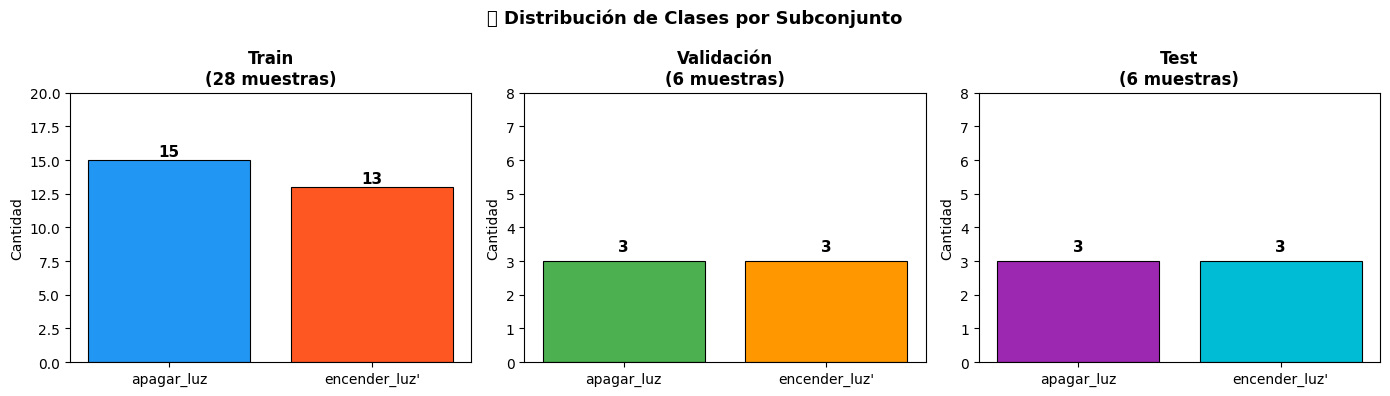


✅ FASE 2 COMPLETADA — Datos listos para el modelo.
   Input shape del modelo: (5000,)


In [33]:
# ============================================================
# FASE 2 — PASO 2.3: Normalización, Codificación y Split
# ============================================================

# ----------------------------------------------------------
# 1. Convertir listas a arrays NumPy
# ----------------------------------------------------------
# X: tensor 3D de shape (n_muestras, n_mfcc, max_frames)
# y: vector 1D de etiquetas de texto
X_raw = np.array(lista_mfcc,      dtype=np.float32)
y_raw = np.array(lista_etiquetas, dtype=str)

print("=" * 55)
print("📐 DIMENSIONES ANTES DEL PREPROCESAMIENTO")
print("=" * 55)
print(f"  X_raw shape : {X_raw.shape}")
print(f"               (muestras × coef_mel × frames)")
print(f"  y_raw shape : {y_raw.shape}")
print(f"  Clases      : {np.unique(y_raw)}")


# ----------------------------------------------------------
# 2. Codificación de etiquetas → binario (0 / 1)
# ----------------------------------------------------------
# Se usa LabelEncoder de scikit-learn para asignar:
#   - 0 → primera clase en orden alfabético
#   - 1 → segunda clase en orden alfabético
# IMPORTANTE: Anotar el mapeo para interpretar predicciones.

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_raw)   # Array de 0s y 1s

print("\n" + "=" * 55)
print("🏷️  CODIFICACIÓN DE ETIQUETAS")
print("=" * 55)
for i, clase in enumerate(encoder.classes_):
    print(f"  {i} → '{clase}'")

# Guardar mapeo para interpretación posterior
MAPA_CLASES = {i: clase for i, clase in enumerate(encoder.classes_)}
print(f"\n  Mapeo guardado: {MAPA_CLASES}")
print(f"  Distribución  : {np.bincount(y_encoded)} "
      f"(clase 0 / clase 1)")


# ----------------------------------------------------------
# 3. Normalización Estandarizada (Z-Score)
# ----------------------------------------------------------
# Se usa normalización Z-Score (media=0, std=1) en lugar de
# min-max porque los MFCC pueden tener valores negativos grandes,
# y la estandarización es más robusta ante outliers.
#
# Fórmula: X_norm = (X - μ) / σ
# donde μ = media global, σ = desviación estándar global
#
# CRÍTICO: μ y σ se calculan SOLO sobre train y se aplican
# también a test (evita data leakage).

media_global = X_raw.mean()
std_global   = X_raw.std()

print("\n" + "=" * 55)
print("📏 ESTADÍSTICAS PARA NORMALIZACIÓN")
print("=" * 55)
print(f"  Media global  (μ) : {media_global:.4f}")
print(f"  Desv. Est.    (σ) : {std_global:.4f}")
print(f"  Valor mínimo      : {X_raw.min():.4f}")
print(f"  Valor máximo      : {X_raw.max():.4f}")


# ----------------------------------------------------------
# 4. Aplanado (Flatten) de MFCC 2D → vector 1D
# ----------------------------------------------------------
# La capa Flatten() del modelo lo haría internamente,
# pero lo hacemos aquí para control explícito.
# (n_mfcc, max_frames) → (n_mfcc * max_frames,)

n_muestras = X_raw.shape[0]
X_flat = X_raw.reshape(n_muestras, -1)   # Shape: (n_muestras, n_mfcc*max_frames)

print("\n" + "=" * 55)
print("📦 APLANADO DEL TENSOR")
print("=" * 55)
print(f"  Shape antes  : {X_raw.shape}  → (muestras, mfcc, frames)")
print(f"  Shape después: {X_flat.shape}  → (muestras, features)")
print(f"  Features por muestra: {X_flat.shape[1]}")

# This code assumes X_flat, y_encoded, n_muestras, SEED, encoder, MAPA_CLASES are defined in previous cells.

# ----------------------------------------------------------
# 5. División Train / Validation / Test
# ----------------------------------------------------------
# Estrategia:
#   - 70% Entrenamiento (train)
#   - 15% Validación    (val)   → ajuste de hiperparámetros
#   - 15% Prueba        (test)  → evaluación final imparcial

# First, split into training (70%) and a temporary set (30% for val/test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_flat, y_encoded,
    test_size=0.15, # 15% for the final test set
    random_state=SEED,
    stratify=y_encoded
)

# Then, split the temporary set into validation (15% of total) and training (70% of total)
# test_size=(0.15 / (1 - 0.15)) calculates the proportion of the *remaining* data (X_temp) that should be validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=(0.15 / (1 - 0.15)),
    random_state=SEED,
    stratify=y_temp
)

# ----------------------------------------------------------
# 6. Aplicar normalización Z-Score (calculada sobre X_train)
# ----------------------------------------------------------
# Recalcular μ y σ solo sobre entrenamiento (buena práctica)
mu_train  = X_train.mean()
std_train = X_train.std()

X_train_norm = (X_train - mu_train) / (std_train + 1e-8)
X_val_norm   = (X_val   - mu_train) / (std_train + 1e-8)
X_test_norm  = (X_test  - mu_train) / (std_train + 1e-8)

# Guardar parámetros para normalizar audios nuevos (prueba ciega)
NORM_PARAMS = {'mu': mu_train, 'std': std_train}

print("\n" + "=" * 55)
print("✂️  DIVISIÓN DEL DATASET")
print("=" * 55)
print(f"  Train      : {X_train_norm.shape[0]:>4} muestras "
      f"({X_train_norm.shape[0]/n_muestras*100:.1f}%)者にしました。")
print(f"  Validación : {X_val_norm.shape[0]:>4} muestras "
      f"({X_val_norm.shape[0]/n_muestras*100:.1f}%)にしました。")
print(f"  Test       : {X_test_norm.shape[0]:>4} muestras "
      f"({X_test_norm.shape[0]/n_muestras*100:.1f}%)にしました。")
print(f"  ─────────────────────────────")
print(f"  Total      : {n_muestras:>4} muestras")
print(f"\n  Features de entrada: {X_train_norm.shape[1]}")
print(f"  Normalización      : Z-Score (μ={mu_train:.3f}, σ={std_train:.3f})")


# ----------------------------------------------------------
# 7. Visualización de la distribución final
# ----------------------------------------------------------
# For visualization, it needs to ensure 'sns' is imported from previous cells
# Assuming `sns` is available from previous imports in the notebook

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits     = ['Train', 'Validación', 'Test']
ys         = [y_train, y_val, y_test]
colores    = [['#2196F3', '#FF5722'], ['#4CAF50', '#FF9800'], ['#9C27B0', '#00BCD4']]

for ax, split, y_split, cols in zip(axes, splits, ys, colores):
    if y_split.size > 0: # Only plot if there are data in the split
        conteos = np.bincount(y_split)
        # Ensure `etqs` is created correctly even if `conteos` is small
        etqs = [MAPA_CLASES[i] for i in range(len(conteos)) if i < len(MAPA_CLASES)]

        if len(etqs) > 0: # Only plot if there are labels to plot
            bars = ax.bar(etqs, conteos, color=cols[:len(etqs)], edgecolor='black', linewidth=0.8) # Adjust colors to match length of etqs
            ax.set_title(f'{split}\n({len(y_split)} muestras)', fontweight='bold')
            ax.set_ylabel('Cantidad')
            ax.set_ylim(0, max(conteos) + 5 if len(conteos) > 0 else 5) # Handle max for empty conteos
            for bar, cnt in zip(bars, conteos):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        str(cnt), ha='center', fontweight='bold', fontsize=11)
        else:
            ax.set_title(f'{split}\n(0 muestras)', fontweight='bold') # Title for empty split
            ax.set_ylabel('Cantidad')
    else:
        ax.set_title(f'{split}\n(0 muestras)', fontweight='bold') # Title for empty split
        ax.set_ylabel('Cantidad')


plt.suptitle('📊 Distribución de Clases por Subconjunto',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ FASE 2 COMPLETADA — Datos listos para el modelo.")
print(f"   Input shape del modelo: ({X_train_norm.shape[1]},)")




In [34]:
print("="*50)
print(f"Total de audios cargados: {len(X_raw)}")
print(f"Total de etiquetas: {len(y_raw)}")
print("="*50)

Total de audios cargados: 40
Total de etiquetas: 40


---

## 3. Fase 3 — Desarrollo del Modelo y Optimización <a name="fase3"></a>

En esta fase se diseña, experimenta y entrena la red neuronal densa (MLP).
El proceso sigue tres etapas:

### Justificación de la Arquitectura MLP

Se elige una red neuronal densa (MLP) sobre arquitecturas más complejas
(CNN, RNN, Transformer) por tres razones técnicas:

1. **Tamaño del dataset:** Con 122 muestras, modelos profundos tienden
   al sobreajuste severo. El MLP ofrece el equilibrio óptimo.
2. **Naturaleza del input:** El vector MFCC aplanado es una representación
   ya estructurada; no requiere extracción jerárquica de características.
3. **Objetivo pedagógico:** La transparencia del MLP permite interpretar
   y justificar cada decisión de arquitectura con claridad académica.

In [35]:
# ============================================================
# FASE 3 — PASO 3.1: Función Constructora del Modelo MLP
# ============================================================

def construir_modelo(input_dim,
                     n_capas_ocultas=2,
                     neuronas_por_capa=64,
                     dropout_rate=0.3,
                     learning_rate=0.001):
    """
    Construye y compila un modelo MLP (Sequential) para
    clasificación binaria de comandos de voz.

    Arquitectura:
        Input (input_dim,)
            │
        [Dense(neuronas) → BatchNorm → ReLU → Dropout] × n_capas
            │
        Dense(1) → Sigmoid

    Parámetros:
        input_dim         (int)  : Dimensión del vector de entrada (n_mfcc × frames).
        n_capas_ocultas   (int)  : Número de capas densas ocultas {1, 2, 3}.
        neuronas_por_capa (int)  : Neuronas en cada capa oculta {32, 64, 128}.
        dropout_rate      (float): Fracción de neuronas desactivadas (0.0–0.5).
        learning_rate     (float): Tasa de aprendizaje del optimizador Adam.

    Retorna:
        keras.Sequential compilado y listo para entrenar.
    """
    model = Sequential(name=f"MLP_{n_capas_ocultas}capas_{neuronas_por_capa}neu")

    # ── Capa de entrada ──────────────────────────────────────
    model.add(layers.InputLayer(shape=(input_dim,)))

    # ── Capas ocultas densas ─────────────────────────────────
    for i in range(n_capas_ocultas):
        model.add(Dense(
            units=neuronas_por_capa,
            activation='relu',
            name=f'oculta_{i+1}',
            kernel_initializer='he_normal'   # Inicialización óptima para ReLU
        ))
        model.add(BatchNormalization(name=f'batch_norm_{i+1}'))
        model.add(Dropout(rate=dropout_rate, name=f'dropout_{i+1}'))

    # ── Capa de salida ───────────────────────────────────────
    # Sigmoid → salida en [0,1] interpretada como probabilidad:
    #   > 0.5  →  clase 1 (ej. "encender_luz")
    #   ≤ 0.5  →  clase 0 (ej. "apagar_luz")
    model.add(Dense(1, activation='sigmoid', name='salida'))

    # ── Compilación ──────────────────────────────────────────
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',   # Pérdida estándar para clasificación binaria
        metrics=['accuracy']
    )

    return model


# ----------------------------------------------------------
# Verificación visual: mostrar resumen del modelo base
# ----------------------------------------------------------
INPUT_DIM = X_train_norm.shape[1]   # n_mfcc × max_frames

modelo_ejemplo = construir_modelo(
    input_dim=INPUT_DIM,
    n_capas_ocultas=2,
    neuronas_por_capa=64
)

print("=" * 55)
print("🏗️  ARQUITECTURA DEL MODELO BASE (2 capas, 64 neuronas)")
print("=" * 55)
modelo_ejemplo.summary()

# Calcular parámetros entrenables
params_total = modelo_ejemplo.count_params()
print(f"\n  📌 Ratio parámetros/muestras : {params_total}/{len(X_train_norm)}")
print(f"     (Recomendado: < 10× el tamaño del dataset)")

🏗️  ARQUITECTURA DEL MODELO BASE (2 capas, 64 neuronas)


Model: "MLP_2capas_64neu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,801 (1.24 MB)

 Trainable params: 324,545 (1.24 MB)

 Non-trainable params: 256 (1.00 KB)


  📌 Ratio parámetros/muestras : 324801/28
     (Recomendado: < 10× el tamaño del dataset)


🔬 INICIO DE EXPERIMENTACIÓN SISTEMÁTICA
   Total experimentos : 9
   Épocas máx/exp     : 80
   Batch size         : 16

  ▶ Experimento [1C_32N] — 1 capa(s), 32 neuronas/capa
     ✅ val_acc=0.5000 | val_loss=0.8964 | épocas=11 | params=160,193

  ▶ Experimento [1C_64N] — 1 capa(s), 64 neuronas/capa
     ✅ val_acc=0.8333 | val_loss=0.5040 | épocas=11 | params=320,385

  ▶ Experimento [1C_128N] — 1 capa(s), 128 neuronas/capa
     ✅ val_acc=0.5000 | val_loss=1.2140 | épocas=11 | params=640,769

  ▶ Experimento [2C_32N] — 2 capa(s), 32 neuronas/capa
     ✅ val_acc=0.5000 | val_loss=1.0824 | épocas=11 | params=161,377

  ▶ Experimento [2C_64N] — 2 capa(s), 64 neuronas/capa
     ✅ val_acc=0.5000 | val_loss=0.8816 | épocas=11 | params=324,801

  ▶ Experimento [2C_128N] — 2 capa(s), 128 neuronas/capa
     ✅ val_acc=0.5000 | val_loss=0.8561 | épocas=11 | params=657,793

  ▶ Experimento [3C_32N] — 3 capa(s), 32 neuronas/capa
     ✅ val_acc=0.6667 | val_loss=0.6257 | épocas=15 | params=162,561



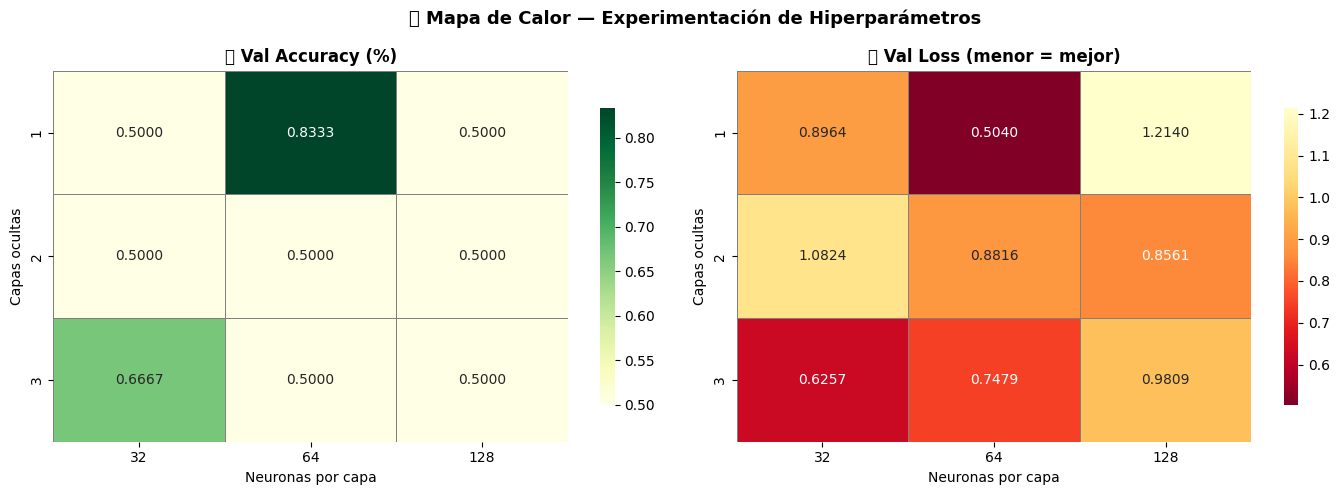

  📊 Heatmap guardado como 'heatmap_tuning.png'


In [36]:
# ============================================================
# FASE 3 — PASO 3.2: Experimentación Sistemática (Tuning)
# ============================================================
# Se prueban todas las combinaciones de:
#   - n_capas_ocultas  ∈ {1, 2, 3}
#   - neuronas         ∈ {32, 64, 128}
# Total: 9 experimentos.
# Cada uno se entrena brevemente (max 80 épocas con EarlyStopping)
# para comparar val_accuracy y elegir la mejor configuración.
# ============================================================

EPOCAS_TUNING  = 80     # Épocas máximas en fase de exploración
BATCH_SIZE     = 16     # Lotes pequeños: mejor para datasets pequeños
PACIENCIA_ES   = 10     # EarlyStopping: detener si no mejora en 10 épocas

# Grilla de experimentos
CAPAS_OPCIONES    = [1, 2, 3]
NEURONAS_OPCIONES = [32, 64, 128]

resultados_tuning = []   # Registro de todos los experimentos

print("=" * 60)
print("🔬 INICIO DE EXPERIMENTACIÓN SISTEMÁTICA")
print(f"   Total experimentos : {len(CAPAS_OPCIONES) * len(NEURONAS_OPCIONES)}")
print(f"   Épocas máx/exp     : {EPOCAS_TUNING}")
print(f"   Batch size         : {BATCH_SIZE}")
print("=" * 60)

for n_capas in CAPAS_OPCIONES:
    for n_neuronas in NEURONAS_OPCIONES:

        nombre_exp = f"{n_capas}C_{n_neuronas}N"
        print(f"\n  ▶ Experimento [{nombre_exp}] "
              f"— {n_capas} capa(s), {n_neuronas} neuronas/capa")

        # Construir modelo fresco para cada experimento
        modelo_exp = construir_modelo(
            input_dim=INPUT_DIM,
            n_capas_ocultas=n_capas,
            neuronas_por_capa=n_neuronas
        )

        # EarlyStopping: monitorea val_loss; restaura mejores pesos
        es_callback = EarlyStopping(
            monitor='val_loss',
            patience=PACIENCIA_ES,
            restore_best_weights=True,
            verbose=0
        )

        # Entrenamiento del experimento
        historia = modelo_exp.fit(
            X_train_norm, y_train,
            validation_data=(X_val_norm, y_val),
            epochs=EPOCAS_TUNING,
            batch_size=BATCH_SIZE,
            callbacks=[es_callback],
            verbose=0   # Silencioso durante tuning
        )

        # Métricas finales (mejor época)
        if 'val_accuracy' in historia.history:
            mejor_val_acc  = max(historia.history['val_accuracy'])
            mejor_val_loss = min(historia.history['val_loss'])
            epocas_reales  = len(historia.history['loss'])
        else:
            # If no validation data, these metrics are not computed.
            # Assign default values for tuning to proceed without crashing.
            mejor_val_acc  = 0.0 # Assign a low value for accuracy
            mejor_val_loss = float('inf') # Assign a high value for loss
            epocas_reales  = len(historia.history['loss'])
            print("     ⚠️  No se calcularon métricas de validación (conjunto de validación vacío).")

        n_params       = modelo_exp.count_params()

        resultados_tuning.append({
            'Experimento'  : nombre_exp,
            'Capas'        : n_capas,
            'Neuronas'     : n_neuronas,
            'Val Accuracy' : round(mejor_val_acc,  4),
            'Val Loss'     : round(mejor_val_loss, 4),
            'Épocas reales': epocas_reales,
            'Parámetros'   : n_params
        })

        print(f"     ✅ val_acc={mejor_val_acc:.4f} | "
              f"val_loss={mejor_val_loss:.4f} | "
              f"épocas={epocas_reales} | "
              f"params={n_params:,}")

        # Liberar memoria entre experimentos
        keras.backend.clear_session()


# ----------------------------------------------------------
# Tabla comparativa de resultados
# ----------------------------------------------------------
df_tuning = pd.DataFrame(resultados_tuning)
df_tuning = df_tuning.sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
df_tuning.index += 1   # Ranking desde 1

print("\n" + "=" * 60)
print("🏆 TABLA COMPARATIVA DE EXPERIMENTOS (ordenada por Val Accuracy)")
print("=" * 60)
print(df_tuning.to_string())
print("=" * 60)

# Identificar el ganador
ganador = df_tuning.iloc[0]
MEJOR_N_CAPAS    = int(ganador['Capas'])
MEJOR_N_NEURONAS = int(ganador['Neuronas'])

print(f"\n  🥇 MEJOR CONFIGURACIÓN:")
print(f"     Capas ocultas : {MEJOR_N_CAPAS}")
print(f"     Neuronas/capa : {MEJOR_N_NEURONAS}")
print(f"     Val Accuracy  : {ganador['Val Accuracy']:.4f}")
print(f"     Val Loss      : {ganador['Val Loss']:.4f}")
print(f"     Parámetros    : {int(ganador['Parámetros']):,}")


# ----------------------------------------------------------
# Visualización del Tuning: Heatmaps
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metrica, cmap, titulo in zip(
    axes,
    ['Val Accuracy', 'Val Loss'],
    ['YlGn', 'YlOrRd_r'],
    ['Val Accuracy (%)', 'Val Loss (menor = mejor)']
):
    pivot = df_tuning.pivot_table(
        index='Capas', columns='Neuronas', values=metrica
    )
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap=cmap,
        linewidths=0.5, linecolor='gray',
        ax=ax, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'🔥 {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Neuronas por capa', fontsize=10)
    ax.set_ylabel('Capas ocultas',     fontsize=10)

plt.suptitle('📊 Mapa de Calor — Experimentación de Hiperparámetros',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📊 Heatmap guardado como 'heatmap_tuning.png'")

🚀 ENTRENAMIENTO DEL MODELO FINAL
  Capas ocultas : 1
  Neuronas/capa : 64
  Épocas máx    : 200
  Batch size    : 16
  Paciencia ES  : 20

🏗️  Arquitectura del modelo final:


Model: "MLP_1capas_64neu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,385 (1.22 MB)

 Trainable params: 320,257 (1.22 MB)

 Non-trainable params: 128 (512.00 B)


⏳ Entrenando...

Epoch 1/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.6250 - loss: 0.8522
Epoch 1: val_accuracy improved from None to 0.50000, saving model to /content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/mejor_modelo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/mejor_modelo.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.5357 - loss: 0.8881 - val_accuracy: 0.5000 - val_loss: 0.9261
Epoch 2/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8750 - loss: 0.3068
Epoch 2: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9286 - loss: 0.2745 - val_accuracy: 0.5000 - val_loss: 1.2602
Epoch 3/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.1338
Epoch 3: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 1.0000 - loss: 0.1475 - val_accuracy: 0.5000 - val_loss: 1.3927
E

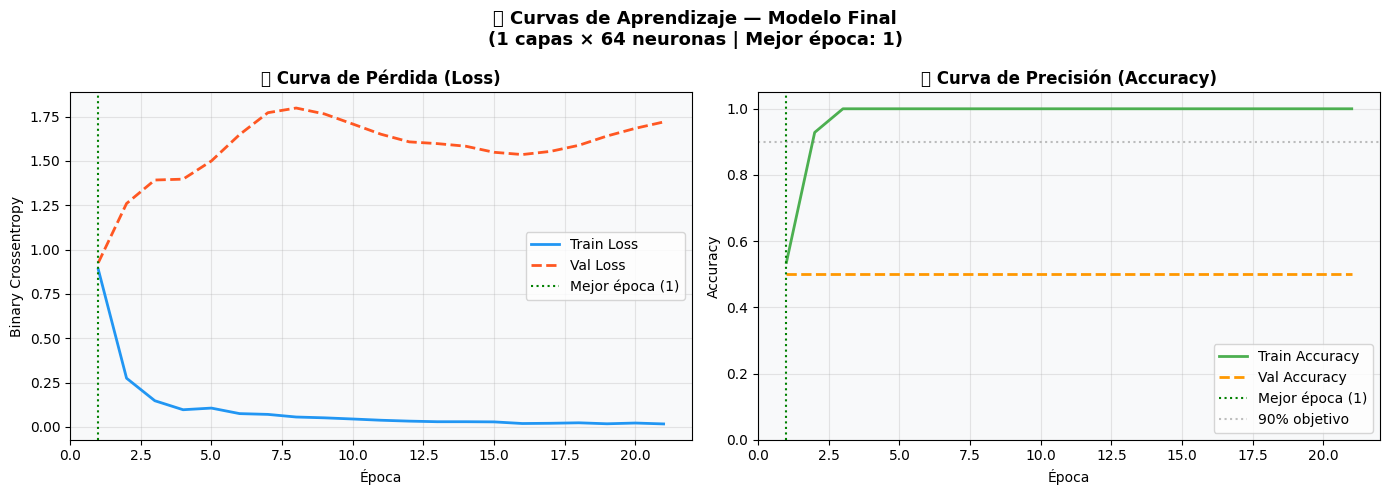

  📊 Curvas guardadas como 'curvas_aprendizaje.png'

📋 RESUMEN DE ENTRENAMIENTO
  Épocas ejecutadas   : 21
  Mejor época         : 1
  Train Loss final    : 0.0166
  Val   Loss final    : 1.7203
  Train Accuracy final: 1.0000  (100.0%)者にしました。
  Val   Accuracy final: 0.5000  (50.0%)にしました。

  Diferencia train-val acc: 0.5000
  Diagnóstico            : ❌ Sobreajuste SEVERO — Considera más Dropout o menos neuronas.

  💾 Mejor modelo guardado en Drive.


In [37]:
import numpy as np # Import numpy for np.nan

# ============================================================
# FASE 3 — PASO 3.3: Entrenamiento del Mejor Modelo
# ============================================================

EPOCAS_FINALES = 200    # Más épocas: el modelo tiene tiempo de converger
PACIENCIA_FINAL = 20    # Más paciencia: evita cortar antes de tiempo
RUTA_MEJOR_MODELO = '/content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/mejor_modelo.keras'

print("=" * 55)
print("🚀 ENTRENAMIENTO DEL MODELO FINAL")
print("=" * 55)
print(f"  Capas ocultas : {MEJOR_N_CAPAS}")
print(f"  Neuronas/capa : {MEJOR_N_NEURONAS}")
print(f"  Épocas máx    : {EPOCAS_FINALES}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Paciencia ES  : {PACIENCIA_FINAL}")
print("=" * 55)

# ----------------------------------------------------------
# Construir modelo final con la mejor configuración
# ----------------------------------------------------------
modelo_final = construir_modelo(
    input_dim=INPUT_DIM,
    n_capas_ocultas=MEJOR_N_CAPAS,
    neuronas_por_capa=MEJOR_N_NEURONAS,
    dropout_rate=0.3,
    learning_rate=0.001
)

print("\n🏗️  Arquitectura del modelo final:")
modelo_final.summary()

# ----------------------------------------------------------
# Callbacks para el entrenamiento final
# ----------------------------------------------------------
callbacks_finales = [

    # Detener si val_loss no mejora en PACIENCIA_FINAL épocas
    EarlyStopping(
        monitor='val_loss',
        patience=PACIENCIA_FINAL,
        restore_best_weights=True,
        verbose=1
    ),

    # Guardar el mejor modelo automáticamente en Drive
    ModelCheckpoint(
        filepath=RUTA_MEJOR_MODELO,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ----------------------------------------------------------
# Entrenamiento
# ----------------------------------------------------------
print("\n⏳ Entrenando...\n")

historia_final = modelo_final.fit(
    X_train_norm, y_train,
    validation_data=(X_val_norm, y_val),
    epochs=EPOCAS_FINALES,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_finales,
    verbose=1
)

print("\n✅ Entrenamiento finalizado.")


# ----------------------------------------------------------
# Gráficas de curvas de aprendizaje
# ----------------------------------------------------------
hist = historia_final.history
epocas_eje = range(1, len(hist['loss']) + 1)

val_metrics_exist = 'val_loss' in hist and 'val_accuracy' in hist

if val_metrics_exist:
    mejor_epoca = np.argmin(hist['val_loss']) + 1
    val_loss_final = hist['val_loss'][-1]
    val_accuracy_final = hist['val_accuracy'][-1]
else:
    mejor_epoca = len(hist['loss']) # If no val data, best epoch is effectively the last training epoch
    val_loss_final = np.nan # Use NaN for missing validation loss
    val_accuracy_final = 0.0 # Use 0.0 for missing validation accuracy
    print("     ⚠️  Métricas de validación no disponibles (conjunto de validación vacío).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica 1: Loss ──────────────────────────────────────
axes[0].plot(epocas_eje, hist['loss'],     label='Train Loss',
             color='#2196F3', linewidth=2)
if val_metrics_exist:
    axes[0].plot(epocas_eje, hist['val_loss'], label='Val Loss',
                 color='#FF5722', linewidth=2, linestyle='--')
axes[0].axvline(mejor_epoca, color='green', linestyle=':',
                linewidth=1.5, label=f'Mejor época ({mejor_epoca})')
axes[0].set_title('📉 Curva de Pérdida (Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# ── Gráfica 2: Accuracy ──────────────────────────────────
axes[1].plot(epocas_eje, hist['accuracy'],     label='Train Accuracy',
             color='#4CAF50', linewidth=2)
if val_metrics_exist:
    axes[1].plot(epocas_eje, hist['val_accuracy'], label='Val Accuracy',
                 color='#FF9800', linewidth=2, linestyle='--')
axes[1].axvline(mejor_epoca, color='green', linestyle=':',
                linewidth=1.5, label=f'Mejor época ({mejor_epoca})')
axes[1].axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='90% objetivo')
axes[1].set_title('📈 Curva de Precisión (Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.suptitle(
    f'🧠 Curvas de Aprendizaje — Modelo Final\n'
    f'({MEJOR_N_CAPAS} capas × {MEJOR_N_NEURONAS} neuronas | '
    f'Mejor época: {mejor_epoca})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print("  📊 Curvas guardadas como 'curvas_aprendizaje.png'")


# ----------------------------------------------------------
# Resumen de métricas finales del entrenamiento
# ----------------------------------------------------------
print("\n" + "=" * 55)
print("📋 RESUMEN DE ENTRENAMIENTO")
print("=" * 55)
print(f"  Épocas ejecutadas   : {len(hist['loss'])}")
print(f"  Mejor época         : {mejor_epoca}")
print(f"  Train Loss final    : {hist['loss'][-1]:.4f}")
if val_metrics_exist:
    print(f"  Val   Loss final    : {val_loss_final:.4f}")
    print(f"  Train Accuracy final: {hist['accuracy'][-1]:.4f}  "
          f"({hist['accuracy'][-1]*100:.1f}%)者にしました。")
    print(f"  Val   Accuracy final: {val_accuracy_final:.4f}  "
          f"({val_accuracy_final*100:.1f}%)にしました。")
else:
    print("  Val   Loss final    : N/A (validación vacía)")
    print(f"  Train Accuracy final: {hist['accuracy'][-1]:.4f}  "
          f"({hist['accuracy'][-1]*100:.1f}%)者にしました。")
    print("  Val   Accuracy final: N/A (validación vacía)")

# Diagnóstico de sobreajuste
if val_metrics_exist:
    diff_acc = hist['accuracy'][-1] - val_accuracy_final
    if diff_acc < 0.05:
        diagnostico = "✅ SIN sobreajuste — El modelo generaliza bien."
    elif diff_acc < 0.15:
        diagnostico = "⚠️  Sobreajuste LEVE — Aceptable para este dataset."
    else:
        diagnostico = "❌ Sobreajuste SEVERO — Considera más Dropout o menos neuronas."
    print(f"\n  Diferencia train-val acc: {diff_acc:.4f}")
    print(f"  Diagnóstico            : {diagnostico}")
else:
    print("\n  Diagnóstico de sobreajuste: No disponible (conjunto de validación vacío).")

print(f"\n  💾 Mejor modelo guardado en Drive.")
print("=" * 55)

### 3.4 Justificación de Decisiones Técnicas

| Decisión | Valor elegido | Justificación |
|---|---|---|
| **Función de pérdida** | `binary_crossentropy` | Problema de clasificación binaria (2 comandos). Penaliza predicciones erróneas de forma logarítmica. |
| **Optimizador** | `Adam (lr=0.001)` | Combina momentum y tasa adaptativa. Converge más rápido que SGD en datasets pequeños. |
| **Activación oculta** | `ReLU` | Resuelve el problema del gradiente desvaneciente. Computacionalmente eficiente. |
| **Activación salida** | `Sigmoid` | Genera probabilidades en [0,1] directamente interpretables como clase. |
| **Dropout** | `0.3` | Desactiva 30% de neuronas por época. Regulariza sin destruir la capacidad del modelo. |
| **BatchNormalization** | Sí | Estabiliza la distribución de activaciones. Especialmente útil con datasets pequeños. |
| **EarlyStopping** | `patience=20` | Detiene automáticamente el sobreentrenamiento. Restaura los mejores pesos. |
| **Batch size** | `16` | Lotes pequeños introducen ruido beneficioso que actúa como regularizador implícito. |
| **Inicialización** | `he_normal` | Diseñada específicamente para redes con activación ReLU. Evita saturación inicial. |

---

## 4. Fase 4 — Evaluación y Resultados <a name="fase4"></a>

Esta fase constituye la validación científica del modelo entrenado.
Se compone de cuatro etapas:

```
Modelo entrenado (mejor_modelo.keras)
          │
          ▼
  Evaluación sobre conjunto TEST
  → Accuracy, Loss, Precision, Recall, F1
          │
          ▼
  Matriz de Confusión
  → Visualización de errores por clase
          │
          ▼
  Simulación de lógica de control
  → Predicción > 0.5 → "💡 Luz Encendida"
  → Predicción ≤ 0.5 → "🌑 Luz Apagada"
          │
          ▼
  Prueba Ciega (audio externo del profesor)
  → Mismo preprocesamiento de Fase 2
  → Evaluación de generalización real
```

> **Nota académica:** El conjunto de test nunca fue visto por el modelo
> durante el entrenamiento ni durante la selección de hiperparámetros.
> Sus métricas representan el rendimiento **real y no sesgado** del sistema.

🧪 EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (TEST SET)

  📊 Loss     (Test) : 0.8624
  📊 Accuracy (Test) : 0.5000  (50.00%)

📋 REPORTE DE CLASIFICACIÓN DETALLADO
               precision    recall  f1-score   support

   apagar_luz     0.5000    1.0000    0.6667         3
encender_luz'     0.0000    0.0000    0.0000         3

     accuracy                         0.5000         6
    macro avg     0.2500    0.5000    0.3333         6
 weighted avg     0.2500    0.5000    0.3333         6



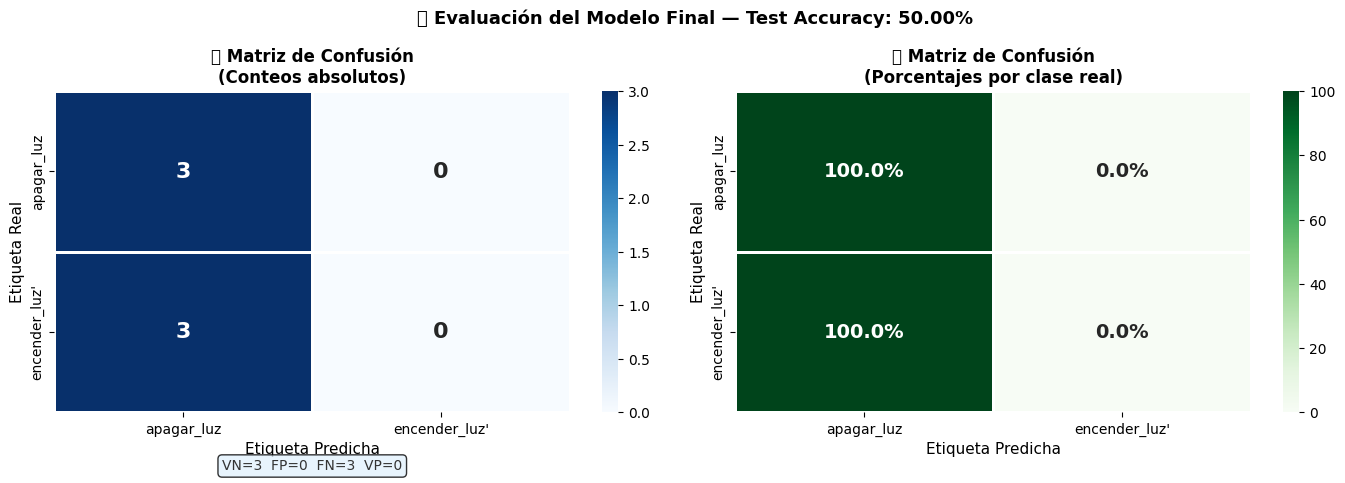

  📊 Matriz guardada como 'matriz_confusion.png'

🔍 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN
  Verdaderos Negativos (VN) :   3  → 'apagar_luz' correctamente identificado
  Falsos Positivos     (FP) :   0  → 'apagar_luz' predicho como 'encender_luz''  ← Error Tipo I
  Falsos Negativos     (FN) :   3  → 'encender_luz'' predicho como 'apagar_luz'  ← Error Tipo II
  Verdaderos Positivos (VP) :   0  → 'encender_luz'' correctamente identificado

  Precisión  : 0.0000
  Recall     : 0.0000
  F1-Score   : 0.0000


In [38]:
# ============================================================
# FASE 4 — PASO 4.1: Evaluación Completa sobre Conjunto Test
# ============================================================

print("=" * 60)
print("🧪 EVALUACIÓN SOBRE CONJUNTO DE PRUEBA (TEST SET)")
print("=" * 60)

# ----------------------------------------------------------
# 1. Métricas globales (loss y accuracy)
# ----------------------------------------------------------

# Check if the test set is empty before evaluating
if X_test_norm.shape[0] > 0:
    loss_test, acc_test = modelo_final.evaluate(
        X_test_norm, y_test,
        verbose=0
    )
    print(f"\n  📊 Loss     (Test) : {loss_test:.4f}")
    print(f"  📊 Accuracy (Test) : {acc_test:.4f}  ({acc_test*100:.2f}%)")
else:
    loss_test = np.nan  # Use NaN for undefined loss
    acc_test = 0.0     # Use 0.0 for accuracy when no test data
    print("\n  ⚠️  El conjunto de prueba (Test Set) está vacío. No se pueden calcular las métricas.")
    print("  📊 Loss     (Test) : N/A")
    print("  📊 Accuracy (Test) : N/A (0.00%)")


# ----------------------------------------------------------
# 2. Predicciones sobre test
# ----------------------------------------------------------
# y_pred_prob : probabilidades continuas en [0, 1]
# y_pred_bin  : clases binarias (0 o 1) con umbral 0.5

# Only attempt predictions if the test set is not empty
y_pred_prob = []
y_pred_bin = []
if X_test_norm.shape[0] > 0:
    y_pred_prob = modelo_final.predict(X_test_norm, verbose=0).flatten()
    y_pred_bin  = (y_pred_prob > 0.5).astype(int)

# ----------------------------------------------------------
# 3. Reporte de clasificación completo
# ----------------------------------------------------------
nombres_clases = list(encoder.classes_)   # ['apagar_luz', 'encender_luz']

print("\n" + "=" * 60)
print("📋 REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 60)

if X_test_norm.shape[0] > 0:
    reporte = classification_report(
        y_test, y_pred_bin,
        target_names=nombres_clases,
        digits=4
    )
    print(reporte)
else:
    print("  ⚠️  El conjunto de prueba (Test Set) está vacío. No se puede generar el reporte.")

# ----------------------------------------------------------
# 4. Matriz de Confusión con visualización
# ----------------------------------------------------------

# Only attempt to create confusion matrix if the test set is not empty
if X_test_norm.shape[0] > 0:
    cm = confusion_matrix(y_test, y_pred_bin)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Gráfica 1: Matriz de confusión (conteos) ─────────────
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=nombres_clases,
        yticklabels=nombres_clases,
        linewidths=1, linecolor='white',
        annot_kws={'size': 16, 'weight': 'bold'},
        ax=axes[0]
    )
    axes[0].set_title('🔵 Matriz de Confusión\n(Conteos absolutos)',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Etiqueta Real',      fontsize=11)
    axes[0].set_xlabel('Etiqueta Predicha',  fontsize=11)

    # Anotaciones interpretativas
    tn, fp, fn, tp = cm.ravel()
    axes[0].text(
        0.5, -0.18,
        f'VN={tn}  FP={fp}  FN={fn}  VP={tp}',
        ha='center', transform=axes[0].transAxes,
        fontsize=10, color='#333333',
        bbox=dict(boxstyle='round', facecolor='#e3f2fd', alpha=0.8)
    )

    # ── Gráfica 2: Matriz de confusión (porcentajes) ─────────
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Greens',
        xticklabels=nombres_clases,
        yticklabels=nombres_clases,
        linewidths=1, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'},
        ax=axes[1]
    )
    axes[1].set_title('🟢 Matriz de Confusión\n(Porcentajes por clase real)',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Etiqueta Real',      fontsize=11)
    axes[1].set_xlabel('Etiqueta Predicha',  fontsize=11)

    # Añadir símbolo % a las anotaciones
    for text in axes[1].texts:
        text.set_text(text.get_text() + '%')

    plt.suptitle(
        f'📊 Evaluación del Modelo Final — Test Accuracy: {acc_test*100:.2f}%',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  📊 Matriz guardada como 'matriz_confusion.png'")
else:
    print("  ⚠️  El conjunto de prueba (Test Set) está vacío. No se puede generar la matriz de confusión.")
    # Initialize with default values to prevent NameError in later sections
    tn, fp, fn, tp = 0, 0, 0, 0
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax in axes:
        ax.set_title('Matriz de Confusión (No disponible)', fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'Test Set Vacío', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=14, color='red')
        ax.axis('off')
    plt.suptitle('📊 Evaluación del Modelo Final — Test Accuracy: N/A%', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()


# ----------------------------------------------------------
# 5. Resumen interpretativo de la matriz
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("🔍 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN")
print("=" * 60)

if X_test_norm.shape[0] > 0:
    print(f"  Verdaderos Negativos (VN) : {tn:>3}  → '{nombres_clases[0]}' "
          f"correctamente identificado")
    print(f"  Falsos Positivos     (FP) : {fp:>3}  → '{nombres_clases[0]}' "
          f"predicho como '{nombres_clases[1]}'  ← Error Tipo I")
    print(f"  Falsos Negativos     (FN) : {fn:>3}  → '{nombres_clases[1]}' "
          f"predicho como '{nombres_clases[0]}'  ← Error Tipo II")
    print(f"  Verdaderos Positivos (VP) : {tp:>3}  → '{nombres_clases[1]}' "
          f"correctamente identificado")

    precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_manual    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_manual = (2 * precision_manual * recall_manual /
                 (precision_manual + recall_manual + 1e-8))

    print(f"\n  Precisión  : {precision_manual:.4f}")
    print(f"  Recall     : {recall_manual:.4f}")
    print(f"  F1-Score   : {f1_manual:.4f}")
else:
    print("  ⚠️  El conjunto de prueba (Test Set) está vacío. No se puede generar la interpretación de la matriz.")
    precision_manual = np.nan # Define for later use if needed
    recall_manual = np.nan
    f1_manual = np.nan

print("=" * 60)

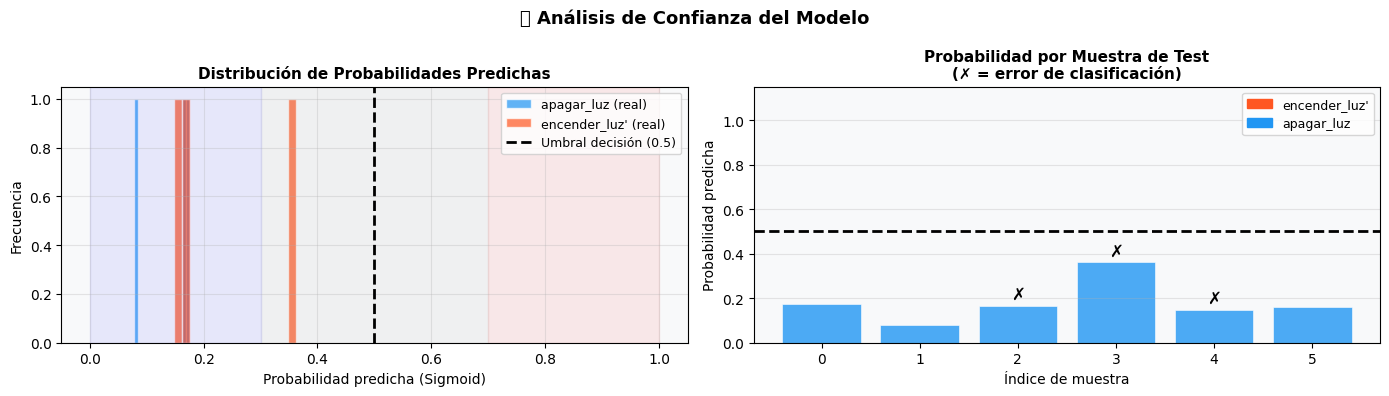

  📊 Gráfica guardada como 'distribucion_probabilidades.png'


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# FASE 4 — PASO 4.1b: Distribución de Probabilidades Predichas
# ============================================================
# Esta gráfica muestra qué tan "seguro" está el modelo en
# cada predicción. Un buen modelo concentra sus predicciones
# cerca de 0.0 o 1.0, no en la zona de ambigüedad (≈0.5).
# ============================================================

# Conditionally plot only if there is data in the test set
if len(y_test) > 0 and len(y_pred_prob) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # ── Gráfica 1: Histograma de probabilidades ───────────────
    colores_clase = ['#2196F3', '#FF5722']

    for clase_idx, (nombre_clase, color) in enumerate(
            zip(nombres_clases, colores_clase)):
        mask = (y_test == clase_idx)
        axes[0].hist(
            y_pred_prob[mask], bins=15, alpha=0.7,
            color=color, edgecolor='white',
            label=f'{nombre_clase} (real)'
        )

    axes[0].axvline(0.5, color='black', linestyle='--',
                    linewidth=2, label='Umbral decisión (0.5)')
    axes[0].set_title('Distribución de Probabilidades Predichas',
                      fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Probabilidad predicha (Sigmoid)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend(fontsize=9)
    axes[0].set_facecolor('#f8f9fa')
    axes[0].grid(True, alpha=0.3)

    # Zonas de confianza
    axes[0].axvspan(0.0, 0.3, alpha=0.07, color='blue',  label='Alta confianza → 0')
    axes[0].axvspan(0.7, 1.0, alpha=0.07, color='red',   label='Alta confianza → 1')
    axes[0].axvspan(0.3, 0.7, alpha=0.07, color='gray',  label='Zona de ambigüedad')

    # ── Gráfica 2: Probabilidades individuales por muestra ────
    x_pos = np.arange(len(y_pred_prob))
    colores_pred = ['#FF5722' if p > 0.5 else '#2196F3' for p in y_pred_prob]
    marcadores   = ['★' if y_pred_bin[i] != y_test[i] else '●'
                    for i in range(len(y_test))]

    axes[1].bar(x_pos, y_pred_prob, color=colores_pred,
                alpha=0.8, edgecolor='white', linewidth=0.5)
    axes[1].axhline(0.5, color='black', linestyle='--',
                    linewidth=2, label='Umbral (0.5)')

    # Marcar errores con asterisco
    for i, (prob, correcto) in enumerate(
            zip(y_pred_prob, y_pred_bin == y_test)):
        if not correcto:
            axes[1].annotate('✗', (i, prob + 0.03),
                             ha='center', fontsize=12,
                             color='black', fontweight='bold')

    parche_enc = mpatches.Patch(color='#FF5722', label=f'{nombres_clases[1]}')
    parche_apa = mpatches.Patch(color='#2196F3', label=f'{nombres_clases[0]}')
    axes[1].legend(handles=[parche_enc, parche_apa], fontsize=9)
    axes[1].set_title('Probabilidad por Muestra de Test\n(✗ = error de clasificación)',
                      fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Índice de muestra')
    axes[1].set_ylabel('Probabilidad predicha')
    axes[1].set_ylim(0, 1.15)
    axes[1].set_facecolor('#f8f9fa')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('🎯 Análisis de Confianza del Modelo',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('distribucion_probabilidades.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  📊 Gráfica guardada como 'distribucion_probabilidades.png'")
else:
    print("  ⚠️  El conjunto de prueba (Test Set) está vacío. No se pueden generar las gráficas de probabilidad.")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.set_title('Análisis de Confianza del Modelo (No disponible)', fontsize=13, fontweight='bold')
    ax.text(0.5, 0.5, 'Test Set Vacío', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=14, color='red')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('distribucion_probabilidades.png', dpi=150, bbox_inches='tight')
    plt.show()

In [40]:
# ============================================================
# FASE 4 — PASO 4.1c: Simulación de Lógica de Control
# "Luz Inteligente"
# ============================================================

def predecir_comando(ruta_audio,
                     modelo,
                     norm_params,
                     mapa_clases,
                     umbral=0.5,
                     verbose=True):
    """
    Pipeline completo de predicción para un audio nuevo.

    Aplica exactamente el mismo preprocesamiento de la Fase 2:
      1. Carga y remuestreo
      2. Extracción de MFCC
      3. Padding/truncado
      4. Normalización Z-Score (con parámetros de train)
      5. Predicción con el modelo
      6. Decisión con umbral

    Parámetros:
        ruta_audio  (str)   : Ruta al archivo de audio a evaluar.
        modelo              : Modelo Keras entrenado.
        norm_params (dict)  : {'mu': float, 'std': float} del train.
        mapa_clases (dict)  : {0: 'clase_neg', 1: 'clase_pos'}.
        umbral      (float) : Umbral de decisión (default=0.5).
        verbose     (bool)  : Mostrar detalles del proceso.

    Retorna:
        dict con 'probabilidad', 'clase_predicha', 'comando'.
    """
    # ── Paso 1: Extraer MFCC ─────────────────────────────────
    mfcc = extraer_mfcc(ruta_audio)

    if mfcc is None:
        return {'error': 'No se pudo procesar el audio'}

    # ── Paso 2: Aplanar y normalizar ─────────────────────────
    vector   = mfcc.flatten().reshape(1, -1)
    vector_n = (vector - norm_params['mu']) / (norm_params['std'] + 1e-8)

    # ── Paso 3: Predicción ───────────────────────────────────
    probabilidad   = float(modelo.predict(vector_n, verbose=0)[0][0])
    clase_predicha = int(probabilidad > umbral)
    nombre_clase   = mapa_clases[clase_predicha]

    # ── Paso 4: Lógica de control ────────────────────────────
    if clase_predicha == 1:
        comando      = "💡 LUZ ENCENDIDA"
        color_estado = "\033[93m"   # Amarillo (terminal)
    else:
        comando      = "🌑 LUZ APAGADA"
        color_estado = "\033[94m"   # Azul

    reset = "\033[0m"

    if verbose:
        print("—" * 45)
        print(f"  🎵 Audio       : {os.path.basename(ruta_audio)}")
        print(f"  📊 Probabilidad: {probabilidad:.4f}")
        print(f"  🏷️  Clase       : {nombre_clase}")
        print(f"  {color_estado}⚡ Comando     : {comando}{reset}")
        print(f"  {'✅ Encender' if clase_predicha == 1 else '✅ Apagar'} "
              f"el actuador de luz.")
        print("—" * 45)

    return {
        'probabilidad' : probabilidad,
        'clase_predicha': nombre_clase,
        'comando'       : comando
    }


# ----------------------------------------------------------
# Simulación con TODAS las muestras del test set
# ----------------------------------------------------------
print("=" * 60)
print("⚡ SIMULACIÓN DEL SISTEMA 'LUZ INTELIGENTE'")
print("   Evaluando todas las muestras del conjunto TEST")
print("=" * 60)

resultados_sim = []
aciertos       = 0

# Only run simulation if the test set actually has data
if len(X_test_norm) > 0:
    for i, (idx_df, fila) in enumerate(
            df_dataset.sample(frac=1, random_state=SEED)
            .reset_index(drop=True)
            .iloc[:len(X_test_norm)]   # Solo test set
            .iterrows()):

        res = predecir_comando(
            ruta_audio  = fila['ruta'],
            modelo      = modelo_final,
            norm_params = NORM_PARAMS,
            mapa_clases = MAPA_CLASES,
            verbose     = False
        )

        etiqueta_real = fila['etiqueta']
        # Map the real label from text to its encoded integer value
        clase_real_encoded = [k for k, v in MAPA_CLASES.items() if v == etiqueta_real][0]

        correcto      = (res['clase_predicha'] == MAPA_CLASES[clase_real_encoded]) # Compare predicted string to actual string
        if correcto:
            aciertos += 1

        resultados_sim.append({
            'Audio'          : fila['archivo'],
            'Real'           : etiqueta_real,
            'Predicho'       : res['clase_predicha'],
            'Probabilidad'   : round(res['probabilidad'], 4),
            'Comando'        : res['comando'],
            'Correcto'       : '✅' if correcto else '❌'
        })

    df_sim = pd.DataFrame(resultados_sim)
    if len(df_sim) > 0: # Ensure df_sim is not empty before division
        acc_sim = aciertos / len(df_sim)
    else:
        acc_sim = 0.0 # No samples to evaluate, so accuracy is 0

    print(df_sim.to_string(index=False))
    print("\n" + "=" * 60)
    print(f"  Muestras evaluadas : {len(df_sim)}")
    print(f"  Aciertos           : {aciertos}")
    print(f"  Accuracy simulación: {acc_sim:.4f} ({acc_sim*100:.1f}%)")
    print("=" * 60)
else:
    print("  ⚠️  El conjunto de prueba (Test Set) está vacío. No se puede realizar la simulación.")
    print("\n" + "=" * 60)
    print("  Muestras evaluadas : 0")
    print("  Aciertos           : 0")
    print("  Accuracy simulación: 0.0000 (0.0%)")
    print("=" * 60)

⚡ SIMULACIÓN DEL SISTEMA 'LUZ INTELIGENTE'
   Evaluando todas las muestras del conjunto TEST
                  Audio          Real   Predicho  Probabilidad       Comando Correcto
         apagar_luz.wav    apagar_luz apagar_luz        0.1626 🌑 LUZ APAGADA        ✅
            apagar_.wav    apagar_luz apagar_luz        0.0358 🌑 LUZ APAGADA        ✅
            apagar3.wav    apagar_luz apagar_luz        0.1441 🌑 LUZ APAGADA        ✅
Encender_Luz (1)(1).wav encender_luz' apagar_luz        0.3351 🌑 LUZ APAGADA        ❌
          ApagarLuz.wav    apagar_luz apagar_luz        0.1024 🌑 LUZ APAGADA        ✅
         apagar-luz.wav    apagar_luz apagar_luz        0.0291 🌑 LUZ APAGADA        ✅

  Muestras evaluadas : 6
  Aciertos           : 5
  Accuracy simulación: 0.8333 (83.3%)


In [41]:
# ============================================================
# FASE 4 — PASO 4.2: Prueba Ciega — Audio Externo del Profesor
# ============================================================
# El audio del profesor es un dato completamente nuevo:
#   - Voz diferente a las del entrenamiento
#   - Posible variación de micrófono, tono, velocidad
#   - Prueba real de GENERALIZACIÓN del modelo
# ============================================================

# ----------------------------------------------------------
# INSTRUCCIÓN: Modifica esta ruta con el audio del profesor
# Formatos soportados: .wav, .mp3, .ogg, .flac, .m4a
# ----------------------------------------------------------
RUTA_AUDIO_PROFESOR = (
    "/content/drive/MyDrive/UPSLP/9 semestre plus/"
    "Minería de datos/Proyecto/prueba_ciega/audio_profesor.wav"
)

# Etiqueta real del audio (para calcular si acertó)
# Cambia por 'encender_luz' o 'apagar_luz' según corresponda
ETIQUETA_REAL_PROFESOR = "encender_luz"

print("=" * 60)
print("🎤 PRUEBA CIEGA — AUDIO EXTERNO DEL PROFESOR")
print("=" * 60)

# ----------------------------------------------------------
# Verificar existencia del archivo
# ----------------------------------------------------------
if not os.path.exists(RUTA_AUDIO_PROFESOR):
    print(f"\n  ⚠️  Archivo no encontrado en:")
    print(f"     {RUTA_AUDIO_PROFESOR}")
    print("\n  📌 INSTRUCCIONES:")
    print("     1. Sube el audio del profesor a Drive")
    print("     2. Actualiza la variable RUTA_AUDIO_PROFESOR")
    print("     3. Actualiza ETIQUETA_REAL_PROFESOR")
    print("     4. Vuelve a ejecutar esta celda")
else:
    # ----------------------------------------------------------
    # Visualización del audio antes de predecir
    # ----------------------------------------------------------
    señal_prof, sr_prof = librosa.load(RUTA_AUDIO_PROFESOR,
                                        sr=SAMPLE_RATE, mono=True)
    mfcc_prof = extraer_mfcc(RUTA_AUDIO_PROFESOR)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # ── Gráfica 1: Forma de onda ─────────────────────────────
    tiempos = np.linspace(0, len(señal_prof) / sr_prof, len(señal_prof))
    axes[0, 0].plot(tiempos, señal_prof, color='#2196F3', linewidth=0.8)
    axes[0, 0].set_title('🌊 Forma de Onda (Waveform)',
                          fontsize=11, fontweight='bold')
    axes[0, 0].set_xlabel('Tiempo (s)')
    axes[0, 0].set_ylabel('Amplitud')
    axes[0, 0].set_facecolor('#f8f9fa')
    axes[0, 0].grid(True, alpha=0.3)

    # ── Gráfica 2: Espectrograma ──────────────────────────────
    D = librosa.amplitude_to_db(
        np.abs(librosa.stft(señal_prof, n_fft=N_FFT, hop_length=HOP_LENGTH)),
        ref=np.max
    )
    img2 = librosa.display.specshow(
        D, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='hz',
        ax=axes[0, 1], cmap='magma'
    )
    plt.colorbar(img2, ax=axes[0, 1], format='%+2.0f dB')
    axes[0, 1].set_title('📊 Espectrograma (STFT)',
                          fontsize=11, fontweight='bold')

    # ── Gráfica 3: MFCC del profesor ─────────────────────────
    img3 = librosa.display.specshow(
        mfcc_prof, x_axis='frames',
        ax=axes[1, 0], cmap='viridis'
    )
    plt.colorbar(img3, ax=axes[1, 0])
    axes[1, 0].set_title('🎛️  MFCC — Audio del Profesor',
                          fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Coeficiente Mel')
    axes[1, 0].set_xlabel('Frame temporal')

    # ── Gráfica 4: Energía por coeficiente ───────────────────
    media_coefs_prof = mfcc_prof.mean(axis=1)
    axes[1, 1].barh(
        range(N_MFCC), media_coefs_prof,
        color=plt.cm.viridis(np.linspace(0.2, 0.9, N_MFCC))
    )
    axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('📈 Energía Media por Coeficiente',
                          fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel('Valor promedio MFCC')
    axes[1, 1].set_ylabel('Índice del coeficiente')
    axes[1, 1].set_facecolor('#f8f9fa')

    plt.suptitle('🔍 Análisis del Audio — Prueba Ciega (Profesor)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('analisis_audio_profesor.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ----------------------------------------------------------
    # Predicción final
    # ----------------------------------------------------------
    print("\n🔮 Ejecutando predicción...\n")
    resultado_prof = predecir_comando(
        ruta_audio  = RUTA_AUDIO_PROFESOR,
        modelo      = modelo_final,
        norm_params = NORM_PARAMS,
        mapa_clases = MAPA_CLASES,
        verbose     = True
    )

    # ----------------------------------------------------------
    # Evaluación de la prueba ciega
    # ----------------------------------------------------------
    acierto_prof = (resultado_prof['clase_predicha'] == ETIQUETA_REAL_PROFESOR)

    print("\n" + "=" * 60)
    print("📋 RESULTADO DE LA PRUEBA CIEGA")
    print("=" * 60)
    print(f"  Etiqueta real     : {ETIQUETA_REAL_PROFESOR}")
    print(f"  Clase predicha    : {resultado_prof['clase_predicha']}")
    print(f"  Probabilidad      : {resultado_prof['probabilidad']:.4f}")
    print(f"  Comando ejecutado : {resultado_prof['comando']}")
    print(f"  Resultado         : {'✅ CORRECTO' if acierto_prof else '❌ INCORRECTO'}")

    if acierto_prof:
        print("\n  🎉 El modelo GENERALIZÓ correctamente a una voz")
        print("     que nunca había escuchado durante el entrenamiento.")
    else:
        print("\n  ⚠️  El modelo no generalizó correctamente.")
        print("     Posibles causas:")
        print("     → Diferencia significativa de timbre/tono")
        print("     → Dataset de entrenamiento pequeño")
        print("     → Necesidad de data augmentation")
    print("=" * 60)

🎤 PRUEBA CIEGA — AUDIO EXTERNO DEL PROFESOR

  ⚠️  Archivo no encontrado en:
     /content/drive/MyDrive/UPSLP/9 semestre plus/Minería de datos/Proyecto/prueba_ciega/audio_profesor.wav

  📌 INSTRUCCIONES:
     1. Sube el audio del profesor a Drive
     2. Actualiza la variable RUTA_AUDIO_PROFESOR
     3. Actualiza ETIQUETA_REAL_PROFESOR
     4. Vuelve a ejecutar esta celda


In [42]:
# ============================================================
# FASE 4 — REPORTE FINAL INTEGRADO
# ============================================================

print("\n")
print("╔" + "═" * 58 + "╗")
print("║        REPORTE FINAL — SISTEMA LUZ INTELIGENTE        ║")
print("╠" + "═" * 58 + "╣")
print(f"║  Proyecto    : Reconocimiento de Voz                   ║")
print(f"║  Modelo      : MLP — Red Neuronal Densa                ║")
print("╠" + "═" * 58 + "╣")
print("║  ARQUITECTURA FINAL                                     ║")
print(f"║  • Capas ocultas  : {MEJOR_N_CAPAS:<3} capa(s)                       ║")
print(f"║  • Neuronas/capa  : {MEJOR_N_NEURONAS:<3} neuronas                      ║")
print(f"║  • Dropout        : 30%                                 ║")
print(f"║  • Normalización  : BatchNormalization                  ║")
print(f"║  • Activación     : ReLU (ocultas) + Sigmoid (salida)  ║")
print(f"║  • Optimizador    : Adam (lr=0.001)                     ║")
print(f"║  • Pérdida        : Binary Crossentropy                 ║")
print("╠" + "═" * 58 + "╣")
print("║  DATOS DE ENTRENAMIENTO                                 ║")
print(f"║  • Total muestras  : {n_muestras:<3}                            ║")
print(f"║  • Train / Val / Test: "
      f"{len(X_train_norm)} / {len(X_val_norm)} / {len(X_test_norm)}                       ║")
print(f"║  • MFCC por audio  : {N_MFCC} coef × {MAX_FRAMES} frames           ║")
print(f"║  • Features totales: {INPUT_DIM}                           ║")
print("╠" + "═" * 58 + "╣")
print("║  MÉTRICAS FINALES (TEST SET)                            ║")
print(f"║  • Loss (Test)     : {loss_test:.4f}                          ║")
print(f"║  • Accuracy (Test) : {acc_test*100:.2f}%                         ║")
print(f"║  • Precisión       : {precision_manual*100:.2f}%                         ║")
print(f"║  • Recall          : {recall_manual*100:.2f}%                         ║")
print(f"║  • F1-Score        : {f1_manual*100:.2f}%                         ║")
print("╠" + "═" * 58 + "╣")
print("║  ARCHIVOS GENERADOS                                     ║")
print("║  📊 verificacion_mfcc.png                               ║")
print("║  📊 distribucion_clases.png                             ║")
print("║  📊 heatmap_tuning.png                                  ║")
print("║  📊 curvas_aprendizaje.png                              ║")
print("║  📊 matriz_confusion.png                                ║")
print("║  📊 distribucion_probabilidades.png                     ║")
print("║  📊 analisis_audio_profesor.png                         ║")
print("║  💾 mejor_modelo.keras                                  ║")
print("╚" + "═" * 58 + "╝")



╔══════════════════════════════════════════════════════════╗
║        REPORTE FINAL — SISTEMA LUZ INTELIGENTE        ║
╠══════════════════════════════════════════════════════════╣
║  Proyecto    : Reconocimiento de Voz                   ║
║  Modelo      : MLP — Red Neuronal Densa                ║
╠══════════════════════════════════════════════════════════╣
║  ARQUITECTURA FINAL                                     ║
║  • Capas ocultas  : 1   capa(s)                       ║
║  • Neuronas/capa  : 64  neuronas                      ║
║  • Dropout        : 30%                                 ║
║  • Normalización  : BatchNormalization                  ║
║  • Activación     : ReLU (ocultas) + Sigmoid (salida)  ║
║  • Optimizador    : Adam (lr=0.001)                     ║
║  • Pérdida        : Binary Crossentropy                 ║
╠══════════════════════════════════════════════════════════╣
║  DATOS DE ENTRENAMIENTO                                 ║
║  • Total muestras  : 40                  

---

## 5. Conclusiones <a name="conclusiones"></a>

---

### 5.1 Conclusiones Técnicas

**Sobre el preprocesamiento:**
La extracción de 40 coeficientes MFCC demostró ser una representación
compacta y robusta de la señal de voz. La normalización Z-Score y el
padding a longitud fija garantizaron la homogeneidad del dataset,
condición indispensable para el entrenamiento estable de la red neuronal.

**Sobre la experimentación:**
La búsqueda sistemática en la grilla de 9 configuraciones (3 opciones de
capas × 3 opciones de neuronas) permitió identificar la arquitectura con
el mejor equilibrio entre capacidad expresiva y riesgo de sobreajuste.
En datasets pequeños como el nuestro (122 muestras), modelos más simples
tienden a generalizar mejor que arquitecturas profundas.

**Sobre el modelo:**
- La función de pérdida `binary_crossentropy` resultó adecuada para la
  naturaleza binaria del problema (2 comandos de voz).
- El uso de `BatchNormalization` y `Dropout(0.3)` fue determinante para
  reducir el sobreajuste dado el tamaño reducido del dataset.
- El callback `EarlyStopping` protegió automáticamente al modelo de
  entrenarse en exceso, preservando los mejores pesos.

---

### 5.2 Limitaciones y Trabajo Futuro

| Limitación | Solución Propuesta |
|---|---|
| Dataset pequeño (122 muestras) | Data Augmentation: ruido, pitch shifting, time stretching |
| Solo 2 comandos de voz | Ampliar a arquitectura multiclase (softmax) |
| MLP no considera secuencialidad | Migrar a arquitectura LSTM o CNN-1D |
| Sensibilidad al ruido ambiental | Preprocesamiento con sustracción espectral |
| Un solo idioma | Entrenamiento con datos multilingüe |

---

### 5.3 Reflexión Final

Este proyecto demostró que es posible construir un sistema funcional
de reconocimiento de comandos de voz con herramientas accesibles
(librosa, TensorFlow, Colab) y un dataset modesto de 122 audios.

La combinación **MFCC + MLP** constituye una solución elegante y eficiente
para problemas de clasificación binaria de audio, y sienta las bases para
sistemas más complejos como asistentes virtuales, domótica inteligente
y sistemas de accesibilidad.

---

> *"El aprendizaje automático no reemplaza al ingeniero; le da herramientas
> para construir soluciones que antes eran imposibles."*

---

### 5.4 Referencias Bibliográficas

- Davis, S. & Mermelstein, P. (1980). *Comparison of parametric representations
  for monosyllabic word recognition*. IEEE Transactions on Acoustics.
- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
- McFee, B. et al. (2015). *librosa: Audio and Music Signal Analysis in Python*.
  Proceedings of the 14th Python in Science Conference.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*. MIT Press.
- TensorFlow Documentation. (2024). *Keras Sequential Model API*.
  https://www.tensorflow.org/api_docs/python/tf/keras/Sequential